In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from typing import List, Dict
from typing import Dict, List

In [111]:
acc1 = pd.read_csv('../data/acc1.csv')
acc2 = pd.read_csv('../data/acc2.csv')

In [112]:
acc1["Account"] = "Chequing"
acc2["Account"] = "Savings"

bank_df_raw = pd.concat([acc1, acc2], ignore_index=True)

### First filter (coolumns)

In [113]:
bank_df = bank_df_raw.drop(columns=["Filter", "Type of Transaction"])

### Second filter (removing internal trasactions)

In [114]:
bank_df = bank_df[bank_df["Description"] != "customer transfer cr."]
bank_df = bank_df[bank_df["Description"] != "customer transfer dr."]

In [115]:
bank_df["Sub-description"] = (
    bank_df["Sub-description"]
    .fillna("none")         # fill NaN
    .replace("", "none")    # fill empty strings
)

# fill when there is just spaces 
bank_df.loc[bank_df["Sub-description"].str.strip() == "", "Sub-description"] = "none"

### Dropping the initial deposits and parent's deposits

In [116]:
bank_df = bank_df[~((bank_df["Description"] == "deposit") & (bank_df["Sub-description"] == "none"))]
bank_df = bank_df[bank_df["Description"] != "abm deposit"]
bank_df = bank_df.drop(index=[400, 397, 389, 349])

In [117]:
bank_df['Description'].unique()

array(['payroll deposit', 'withdrawal', 'pos purchase', 'bill payment',
       'correction', 'deposit', 'interest', 'service charge'],
      dtype=object)

In [118]:
bank_df[bank_df['Description'] == 'deposit']

,Date,Description,Sub-description,Amount,Balance,Account
300,2025-05-26,deposit,Free Interac E-Transfer,60.00,4939.80,Chequing
326,2025-05-17,deposit,Free Interac E-Transfer,8.00,5146.12,Chequing
362,2025-09-19,deposit,Free Interac E-Transfer,24.00,2439.38,Savings
363,2025-09-19,deposit,Free Interac E-Transfer,11.53,2415.38,Savings
365,2025-09-17,deposit,Free Interac E-Transfer,434.72,2838.85,Savings
367,2025-09-04,deposit,Free Interac E-Transfer,423.19,2828.13,Savings
370,2025-08-29,deposit,Free Interac E-Transfer,20.00,3829.91,Savings
372,2025-08-21,deposit,Free Interac E-Transfer,428.96,4314.91,Savings
374,2025-08-07,deposit,Free Interac E-Transfer,423.19,4310.95,Savings
379,2025-07-24,deposit,Free Interac E-Transfer,423.19,5697.72,Savings


In [ ]:
# -------------------- helpers --------------------
def normalize_text(s: str) -> str:
    t = (str(s) or "").lower().strip()
    t = re.sub(r"\s+", " ", t)
    # if you want to remove prefixes "apos/opos/fpos", uncomment:
    # t = re.sub(r"^(apos|opos|fpos)\s+", "", t)
    return t

# -------------------- POS rules engine --------------------
def classify_pos_purchase(df: pd.DataFrame, rules: List[Dict]) -> pd.DataFrame:
    """
    Applies rules ONLY to rows with Description == 'pos purchase'.
    First match wins; increasing priority.
    """
    df = df.copy()

    is_pos   = df["Description"].fillna("").map(normalize_text).eq("pos purchase")
    sub_norm = df["Sub-description"].fillna("").map(normalize_text)

    # ensure output columns
    if "Category" not in df.columns: df["Category"] = "Others"
    if "Sub-Category" not in df.columns: df["Sub-Category"] = "None"

    # sort by priority
    rules_sorted = sorted(rules, key=lambda r: r.get("priority", 9999))

    # compile regex when necessary
    for r in rules_sorted:
        if r.get("match_type") == "regex":
            r["_compiled"] = re.compile(r["pattern"], flags=re.I)

    matched = pd.Series(False, index=df.index)
    for r in rules_sorted:
        pat = r["pattern"].lower()
        mt  = r.get("match_type", "contains")

        if mt == "startswith":
            mask = is_pos & ~matched & sub_norm.str.startswith(pat)
        elif mt == "regex":
            mask = is_pos & ~matched & sub_norm.map(lambda x: bool(r["_compiled"].search(x)))
        else:  # contains
            mask = is_pos & ~matched & sub_norm.str.contains(re.escape(pat), regex=True)

        if mask.any():
            df.loc[mask, "Category"]      = r["category"]
            df.loc[mask, "Sub-Category"]  = r.get("sub_category", "None")
            matched |= mask

    # (optional) fallback: unmatched POS
    still_pos_unmatched = is_pos & ~matched
    df.loc[still_pos_unmatched, ["Category","Sub-Category"]] = ["Others", "None"]

    return df

# -------------------- general classification --------------------
def classify_transactions(df: pd.DataFrame, pos_rules: List[Dict]) -> pd.DataFrame:
    """Classifies Class, Category and Sub-Category and calls the POS engine."""
    df = df.copy()

    # defaults
    df["Class"]         = "Expenses"
    df["Category"]      = "Others"
    df["Sub-Category"]  = "None"

    # normalizations
    desc    = df["Description"].fillna("").map(normalize_text)

    # --- Earnings ---
    mask_payroll   = desc.eq("payroll deposit")
    mask_correct   = desc.eq("correction")
    mask_interest  = desc.eq("interest")
    mask_deposit   = desc.eq("deposit")

    df.loc[mask_payroll,  ["Class","Category"]] = ["Earnings","Payment"]
    df.loc[mask_correct,  ["Class","Category"]] = ["Earnings","earnings"]
    df.loc[mask_interest, ["Class","Category"]] = ["Earnings","earnings"]

    df.loc[mask_deposit, "Class"]    = "Earnings"
    df.loc[mask_deposit, "Category"] = "shared bills"
    df.loc[mask_deposit & df["Amount"].between(300, 900, inclusive="neither"), "Category"] = "Payment"

    # --- Withdrawal (specific order -> general) ---
    mask_withdraw = desc.eq("withdrawal")
    df.loc[mask_withdraw & df.index.isin([399, 352, 289]), "Category"] = "Shopping"
    df.loc[mask_withdraw & (df["Amount"] == -1200), ["Category","Sub-Category"]] = ["Bills","Rent"]
    df.loc[mask_withdraw & df["Category"].eq("Others"), "Category"] = "Money Sent"

    # --- Bill payment / Service charge ---
    df.loc[desc.eq("bill payment"),   ["Category","Sub-Category"]] = ["Bills","Cellphone"]
    df.loc[desc.eq("service charge"), ["Category","Sub-Category"]] = ["Bills","Bank"]

    # --- POS purchase: everything is handled inside the dedicated function ---
    df = classify_pos_purchase(df, pos_rules)

    return df

# Example of “rules” (can come from CSV)
pos_rules = [
    # ===================== Transport =====================
    {"pattern": "compass",           "category": "Bills",      "sub_category": "Transport", "priority": 1, "match_type": "startswith"},
    {"pattern": "compass vending",   "category": "Bills",      "sub_category": "Transport", "priority": 1, "match_type": "contains"},
    {"pattern": "bcf-dep self se",   "category": "Services",  "sub_category": "Nanaimo",   "priority": 2, "match_type": "contains"},
    {"pattern": "bcf-dep self se",   "category": "Services",  "sub_category": "Nanaimo",   "priority": 2, "match_type": "contains"},

    # ===================== Bills =====================
    {"pattern": "revenue services bc", "category": "Bills", "sub_category": "Msp", "priority": 2, "match_type": "contains"},
    {"pattern": "abc*32130",           "category": "Bills", "sub_category": "Gym", "priority": 2, "match_type": "contains"},

    # ===================== Groceries =====================
    {"pattern": "walmart",           "category": "Groceries", "sub_category": "None",      "priority": 5, "match_type": "contains"},
    {"pattern": "real cdn supers",   "category": "Groceries", "sub_category": "None",      "priority": 5, "match_type": "contains"},
    {"pattern": "save on foods",     "category": "Groceries", "sub_category": "None",      "priority": 5, "match_type": "contains"},
    {"pattern": "t t supermarket",   "category": "Groceries", "sub_category": "None",      "priority": 5, "match_type": "contains"},
    {"pattern": "h-mart",            "category": "Groceries", "sub_category": "None",      "priority": 5, "match_type": "contains"},
    {"pattern": "costco wholesal",   "category": "Groceries", "sub_category": "None",      "priority": 5, "match_type": "contains"},
    {"pattern": "urban fare",        "category": "Groceries", "sub_category": "None",      "priority": 5, "match_type": "contains"},
    {"pattern": "dollarama",         "category": "Groceries", "sub_category": "Discount",  "priority": 6, "match_type": "contains"},
    {"pattern": "dollar tree",       "category": "Groceries", "sub_category": "Discount",  "priority": 6, "match_type": "contains"},
    {"pattern": "london drugs",      "category": "Groceries", "sub_category": "Pharmacy",  "priority": 30,"match_type": "contains"},
    {"pattern": "winners",           "category": "Groceries", "sub_category": "Apparel",   "priority": 30,"match_type": "contains"},
    {"pattern": "7-eleven",          "category": "Groceries", "sub_category": "None",      "priority": 20,"match_type": "contains"},
    {"pattern": "ins market",        "category": "Groceries", "sub_category": "None",      "priority": 20,"match_type": "contains"},
    {"pattern": "liquor",            "category": "Groceries", "sub_category": "Alcohol",   "priority": 21,"match_type": "contains"},

    # ===================== Eating Out =====================
    {"pattern": "mcdonald",          "category": "Eating Out", "sub_category": "Fast Food",      "priority": 10, "match_type": "contains"},
    {"pattern": "kfc",               "category": "Eating Out", "sub_category": "Fast Food",      "priority": 10, "match_type": "contains"},
    {"pattern": "popeyes",           "category": "Eating Out", "sub_category": "Fast Food",      "priority": 10, "match_type": "contains"},
    {"pattern": "subway",            "category": "Eating Out", "sub_category": "Fast Food",      "priority": 10, "match_type": "contains"},
    {"pattern": "fatburger",         "category": "Eating Out", "sub_category": "Burgers",        "priority": 11, "match_type": "contains"},
    {"pattern": "freshslice",        "category": "Eating Out", "sub_category": "Pizza",          "priority": 11, "match_type": "contains"},
    {"pattern": "ramen",             "category": "Eating Out", "sub_category": "Asian",          "priority": 12, "match_type": "contains"},
    {"pattern": "sushi",             "category": "Eating Out", "sub_category": "Asian",          "priority": 12, "match_type": "contains"},
    {"pattern": "shawarma",          "category": "Eating Out", "sub_category": "Middle Eastern", "priority": 12, "match_type": "contains"},
    {"pattern": "tim hortons",       "category": "Eating Out", "sub_category": "Cafe",           "priority": 13, "match_type": "contains"},
    {"pattern": "starbucks",         "category": "Eating Out", "sub_category": "Cafe",           "priority": 13, "match_type": "contains"},
    {"pattern": "lee's donut",       "category": "Eating Out", "sub_category": "Dessert",        "priority": 14, "match_type": "contains"},
    {"pattern": "rain or shi",       "category": "Eating Out", "sub_category": "Dessert",        "priority": 14, "match_type": "contains"},
    {"pattern": "charlatan",         "category": "Eating Out", "sub_category": "Bar",            "priority": 2,  "match_type": "contains"},
    {"pattern": "hungry guys",       "category": "Eating Out", "sub_category": "Bar",            "priority": 2,  "match_type": "contains"},
    {"pattern": "mangos kitchen",    "category": "Eating Out", "sub_category": "Asian",          "priority": 2,  "match_type": "contains"},
    {"pattern": "bbq chicken",       "category": "Eating Out", "sub_category": "Asian",          "priority": 2,  "match_type": "contains"},
    {"pattern": "menya raizo",       "category": "Eating Out", "sub_category": "Asian",          "priority": 2,  "match_type": "contains"},
    {"pattern": "big way hot pot",   "category": "Eating Out", "sub_category": "Asian",          "priority": 2,  "match_type": "contains"},
    {"pattern": "tst-jerusalem",     "category": "Eating Out", "sub_category": "Middle Eastern", "priority": 2,  "match_type": "contains"},
    {"pattern": "rio brazilian",     "category": "Eating Out", "sub_category": "Latin",          "priority": 2,  "match_type": "contains"},
    {"pattern": "boteco brasil",     "category": "Eating Out", "sub_category": "Latin",          "priority": 2,  "match_type": "contains"},
    {"pattern": "brazilliant",       "category": "Eating Out", "sub_category": "Latin",          "priority": 2,  "match_type": "contains"},
    {"pattern": "the old spaghet",   "category": "Eating Out", "sub_category": "Italian",        "priority": 2,  "match_type": "contains"},
    {"pattern": "trollers fish",     "category": "Eating Out", "sub_category": "Canadian",       "priority": 2,  "match_type": "contains"},
    {"pattern": "dip co. delight",   "category": "Eating Out", "sub_category": "Canadian",       "priority": 2,  "match_type": "contains"},
    {"pattern": "cactus club",       "category": "Eating Out", "sub_category": "Apparel",        "priority": 2,  "match_type": "contains"},

    # ===================== Shopping =====================
    {"pattern": "herschel",          "category": "Shopping", "sub_category": "Apparel",      "priority": 2, "match_type": "contains"},
    {"pattern": "tommy hilfiger",    "category": "Shopping", "sub_category": "Apparel",      "priority": 2, "match_type": "contains"},
    {"pattern": "roots mcarthur",    "category": "Shopping", "sub_category": "Apparel",      "priority": 2, "match_type": "contains"},
    {"pattern": "under armour",      "category": "Shopping", "sub_category": "Apparel",      "priority": 2, "match_type": "contains"},
    {"pattern": "best buy",          "category": "Shopping", "sub_category": "Electronics",  "priority": 30,"match_type": "contains"},
    {"pattern": "sephora",           "category": "Shopping", "sub_category": "Beauty",       "priority": 30,"match_type": "contains"},
    {"pattern": "decathlon",         "category": "Shopping", "sub_category": "Sports",       "priority": 30,"match_type": "contains"},
    {"pattern": "sport chek",        "category": "Shopping", "sub_category": "Sports",       "priority": 30,"match_type": "contains"},
    {"pattern": "uniqlo",            "category": "Shopping", "sub_category": "Apparel",      "priority": 30,"match_type": "contains"},
    {"pattern": "nike",              "category": "Shopping", "sub_category": "Apparel",      "priority": 30,"match_type": "contains"},
    {"pattern": "north face",        "category": "Shopping", "sub_category": "Apparel",      "priority": 30,"match_type": "contains"},
    {"pattern": "browns shoes",      "category": "Shopping", "sub_category": "Shoes",        "priority": 30,"match_type": "contains"},
    {"pattern": "shoppers drug",     "category": "Shopping", "sub_category": "Barber machine","priority": 2,"match_type": "contains"},
    {"pattern": "daiso",             "category": "Shopping", "sub_category": "Discount",     "priority": 6, "match_type": "contains"},
    {"pattern": "amzn mktp",         "category": "Shopping", "sub_category": "Amazon",       "priority": 40,"match_type": "contains"},
    {"pattern": "aliexpress",        "category": "Shopping", "sub_category": "AliExpress",   "priority": 40,"match_type": "contains"},
    {"pattern": "temu",              "category": "Shopping", "sub_category": "Temu",         "priority": 40,"match_type": "contains"},

    # ===================== Services =====================
    {"pattern": "driver serv.cen",   "category": "Services", "sub_category": "BCID",          "priority": 2, "match_type": "contains"},
    {"pattern": "jay hair salon",    "category": "Services", "sub_category": "Hair cut",      "priority": 2, "match_type": "contains"},
    {"pattern": "cfs-safecheck",     "category": "Services", "sub_category": "Certification", "priority": 2, "match_type": "contains"},
    {"pattern": "name-cheap",        "category": "Services", "sub_category": "Domains",       "priority": 41,"match_type": "contains"},
    {"pattern": "openai",            "category": "Services", "sub_category": "Salon",      "priority": 41,"match_type": "contains"},
    {"pattern": "hair salon",        "category": "Services",   "sub_category": "Salon",         "priority": 50,"match_type": "contains"},
]

#-----------------------------------------------------------------------------------------------------


In [120]:
bank_df = classify_transactions(bank_df, pos_rules)

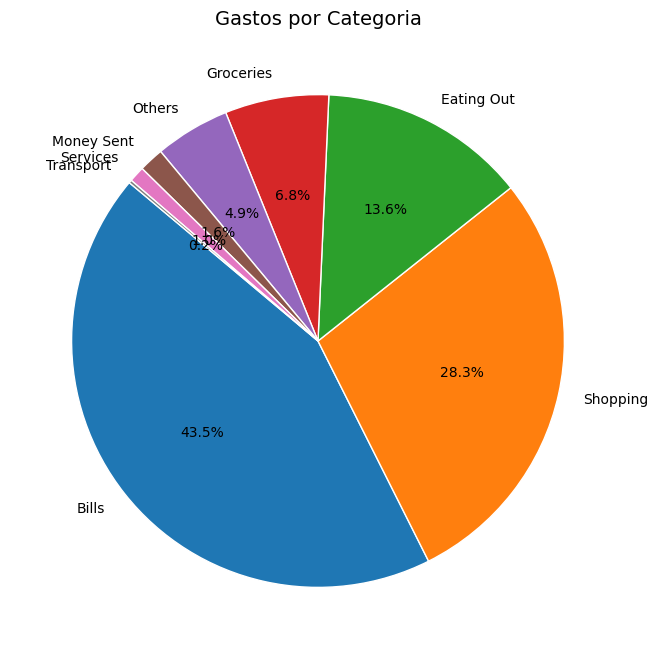

In [121]:
# garantir que Category está preenchido
if "Category" not in bank_df.columns:
    raise ValueError("Category column not found. Run classification first.")

# agregando gastos por categoria (usando valor absoluto do Amount)
category_expenses = (
    bank_df[bank_df["Class"] == "Expenses"]
    .groupby("Category")["Amount"]
    .sum()
    .abs()
)

# ordena para ficar mais bonito
category_expenses = category_expenses.sort_values(ascending=False)

# gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(
    category_expenses,
    labels=category_expenses.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
plt.title("Gastos por Categoria", fontsize=14)
plt.show()

In [122]:
bank_df[bank_df['Category'] == 'Others'].sort_values(by='Amount', ascending=True).head(10)

,Date,Description,Sub-description,Amount,Balance,Account,Class,Category,Sub-Category
109,2025-08-18,pos purchase,Fpos Bcf-Hsb Self Serve Twest,-20.50,3121.25,Chequing,Expenses,Others,None
38,2025-09-11,pos purchase,Apos Fresh Donair Vanco,-14.69,3834.37,Chequing,Expenses,Others,None
70,2025-09-02,pos purchase,Apos Edo Pacific Cen Vanco,-14.65,3935.26,Chequing,Expenses,Others,None
307,2025-05-24,pos purchase,Apos Fat Burger Vanco,-14.63,4940.70,Chequing,Expenses,Others,None
333,2025-05-15,pos purchase,Apos Jollibee Vanco,-14.47,5398.84,Chequing,Expenses,Others,None
77,2025-08-30,pos purchase,Apos Sq *Whatafood New W,-13.80,3770.66,Chequing,Expenses,Others,None
238,2025-06-16,pos purchase,Apos Grouse Mountain N-Van,-12.40,854.98,Chequing,Expenses,Others,None
244,2025-06-12,pos purchase,Apos Pizza Hut 31163 Burna,-11.54,937.66,Chequing,Expenses,Others,None
108,2025-08-18,pos purchase,Apos Mon Petit Choux Nanai,-11.48,3109.77,Chequing,Expenses,Others,None
67,2025-09-02,pos purchase,Apos Sq *Kaisereck D Vanco,-10.98,3712.04,Chequing,Expenses,Others,None


In [123]:
bank_df[bank_df['Category'] == 'Shopping']['Sub-Category'].unique()

array(['Apparel', 'Barber machine', 'AliExpress', 'Electronics',
       'Discount', 'Beauty', 'Shoes', 'Sports', 'Temu', 'Amazon', 'None'],
      dtype=object)

In [124]:
bank_df[bank_df['Category'] == 'Bills']

,Date,Description,Sub-description,Amount,Balance,Account,Class,Category,Sub-Category
19,2025-09-19,pos purchase,Opos Abc*32130 Fw Downtow888-8,-15.74,4000.14,Chequing,Expenses,Bills,Gym
24,2025-09-15,bill payment,Koodo Mobile,-28.00,4063.93,Chequing,Expenses,Bills,Cellphone
56,2025-09-05,pos purchase,Opos Abc*32130 Fw Downtow888-8,-15.74,3625.21,Chequing,Expenses,Bills,Gym
68,2025-09-02,pos purchase,Compass Vending Burna,-149.25,3723.02,Chequing,Expenses,Bills,Transport
69,2025-09-02,pos purchase,Opos Abc*32130 Fw Downtow888-8,-62.99,3872.27,Chequing,Expenses,Bills,Gym
72,2025-09-02,withdrawal,Free Interac E-Transfer,-1200.00,3959.04,Chequing,Expenses,Bills,Rent
95,2025-08-22,pos purchase,Opos Abc*32130 Fw Downtow888-8,-15.74,3428.90,Chequing,Expenses,Bills,Gym
99,2025-08-21,pos purchase,Opos Revenue Services Bc Victo,-75.00,3456.70,Chequing,Expenses,Bills,Msp
111,2025-08-15,bill payment,Koodo Mobile,-28.00,3162.75,Chequing,Expenses,Bills,Cellphone
128,2025-08-08,pos purchase,Opos Abc*32130 Fw Downtow888-8,-15.74,2765.97,Chequing,Expenses,Bills,Gym
